<a href="https://colab.research.google.com/github/DrNeethuSRavi/Computer-Vision-Using-Python/blob/main/CVusingPython_Chapter2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving flower.jpg to flower (1).jpg


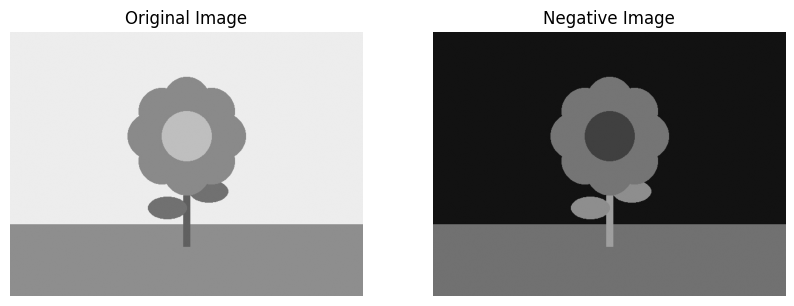

In [2]:
# Image Enhancement

# Image Negative

import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import files

# Upload the image
uploaded = files.upload()

# Read the image in grayscale
img = cv2.imread("flower.jpg", cv2.IMREAD_GRAYSCALE)

# Check whether the image was loaded
if img is None:
    print("Image could not be loaded.")
else:
    # Create the negative image
    negative = 255 - img

    # Display original and negative images
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(negative, cmap="gray", vmin=0, vmax=255)
    plt.title("Negative Image")
    plt.axis("off")

    plt.show()

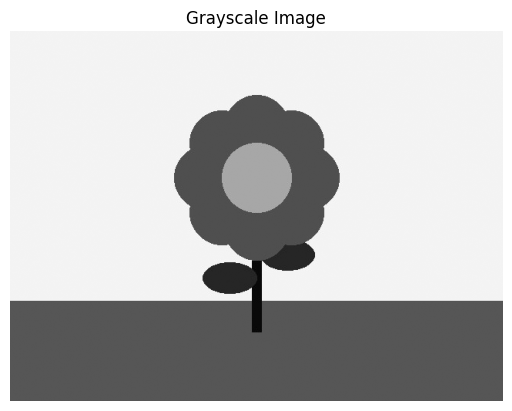

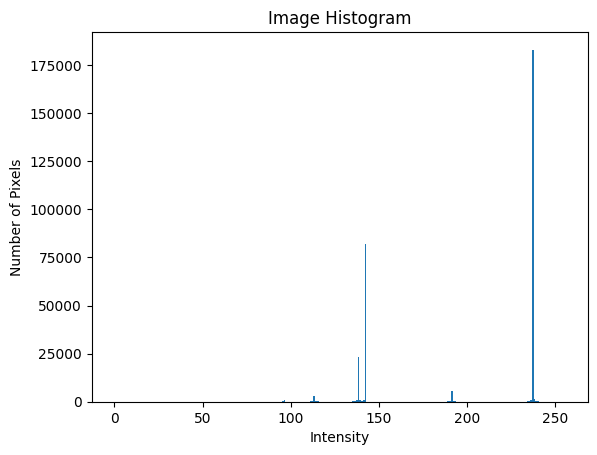

In [3]:
# Histograms

plt.imshow(img, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()
plt.hist(img.ravel(), bins=256, range=[0, 256])
plt.title("Image Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.show()

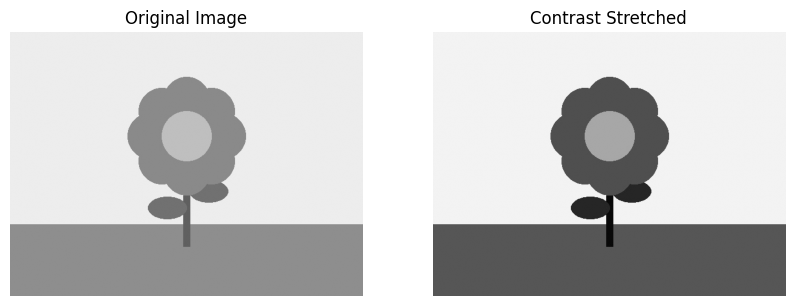

In [4]:
# Contrast Stretching

r_min = img.min()
r_max = img.max()

stretched = (
    (img.astype(np.float32) - r_min)
    * 255.0 / (r_max - r_min)
)

stretched = np.clip(stretched, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(stretched, cmap="gray", vmin=0, vmax=255)
plt.title("Contrast Stretched")
plt.axis("off")
plt.show()

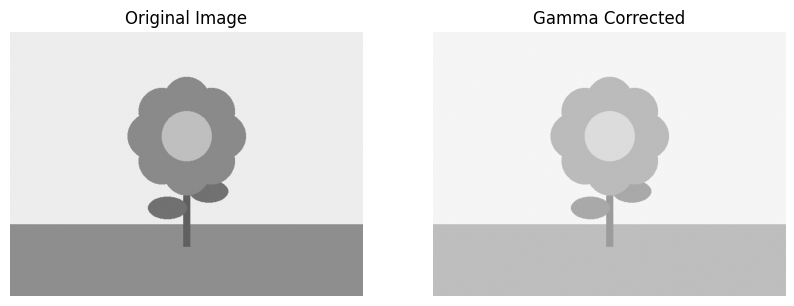

In [5]:
# Gamma Correction

gamma = 0.5
normalized = img.astype(np.float32) / 255.0
corrected = np.power(normalized, gamma)
corrected = np.clip(corrected * 255, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(corrected, cmap="gray", vmin=0, vmax=255)
plt.title("Gamma Corrected")
plt.axis("off")
plt.show()

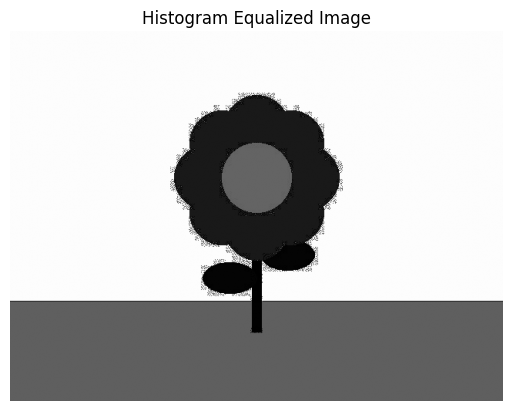

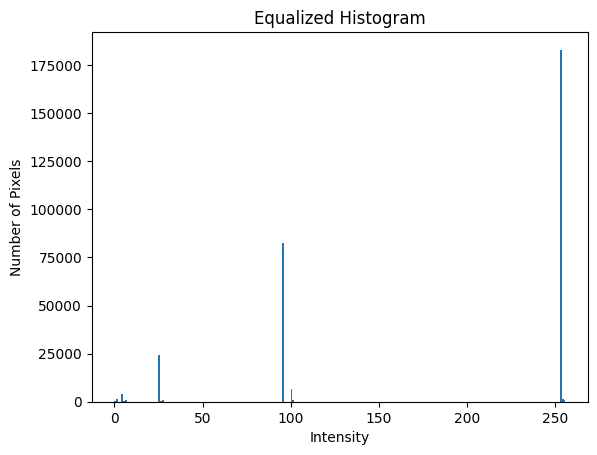

In [6]:
# Histogram Equalization

equalized = cv2.equalizeHist(img)

plt.figure()
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalized Image")
plt.axis("off")
plt.show()

plt.figure()
plt.hist(
    equalized.ravel(),
    bins=256,
    range=[0, 256]
)
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.show()

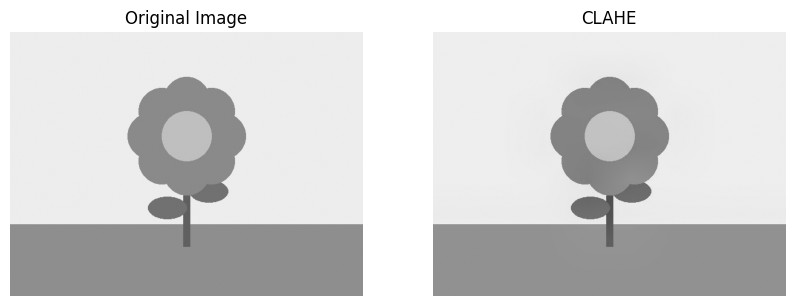

In [8]:
# Contrast Limited Adaptive Histogram Equalization (CLAHE)

clahe = cv2.createCLAHE(
    clipLimit=4.0,
    tileGridSize=(8, 8)
)
clahe_img = clahe.apply(img)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clahe_img, cmap="gray", vmin=0, vmax=255)
plt.title("CLAHE")
plt.axis("off")
plt.show()

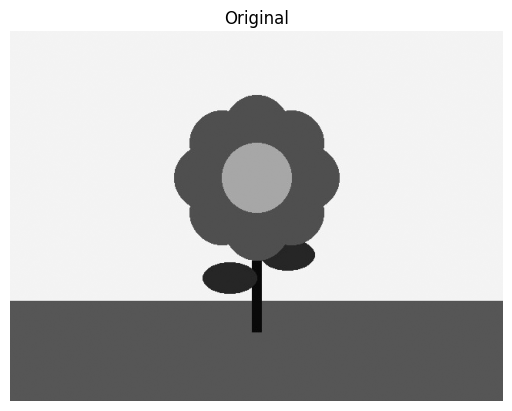

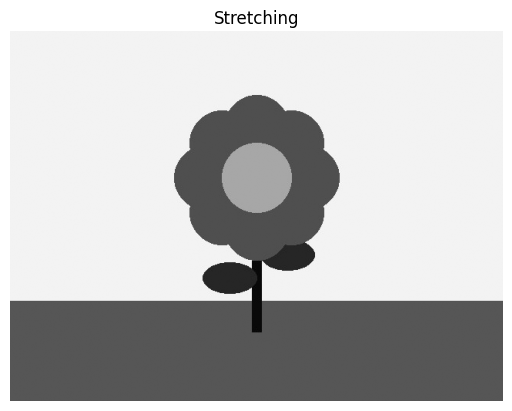

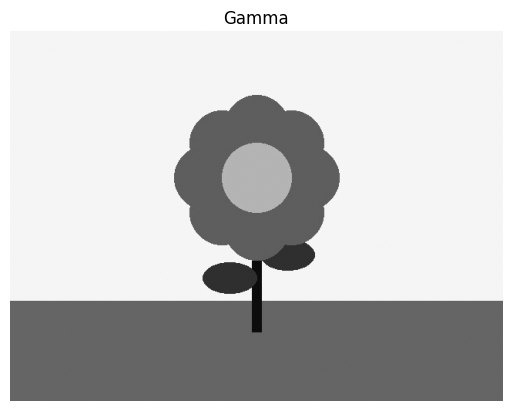

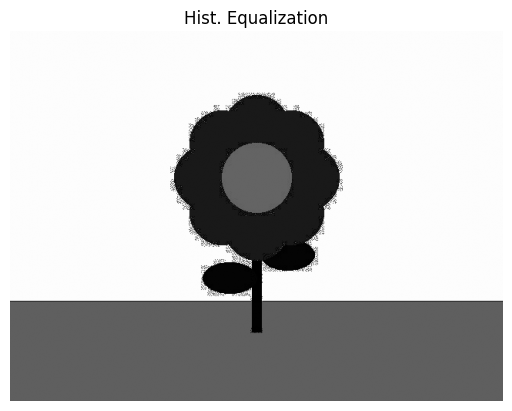

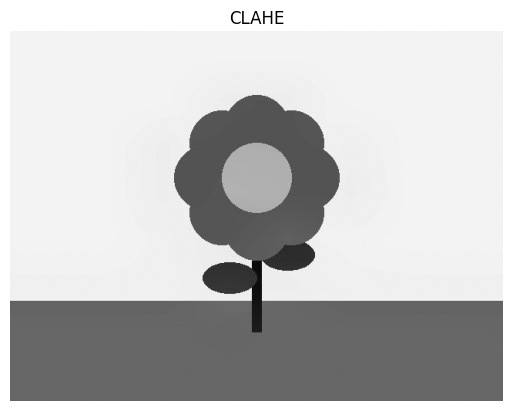

In [9]:
# Methods Comparison

# Contrast stretching
r_min, r_max = img.min(), img.max()
stretch = (
    (img.astype(np.float32) - r_min)
    * 255.0 / (r_max - r_min)
)
stretch = np.clip(
    stretch, 0, 255
).astype(np.uint8)

# Gamma correction
gamma = 0.5
gamma_img = np.power(
    img.astype(np.float32) / 255.0,
    gamma
)
gamma_img = np.clip(
    gamma_img * 255, 0, 255
).astype(np.uint8)

# Histogram equalization
hist_eq = cv2.equalizeHist(img)

# CLAHE
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)
clahe_img = clahe.apply(img)

images = [
    img, stretch, gamma_img,
    hist_eq, clahe_img
]

titles = [
    "Original", "Stretching", "Gamma",
    "Hist. Equalization", "CLAHE"
]

for image, title in zip(images, titles):
    plt.figure()
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()
